# 16 — Outlier Participant Investigation

Investigate human participants with low inter-rater agreement in the pairwise heatmaps.
- Which participants are most misaligned (low mean SBERT/SimCSE)?
- Are they giving short rejections / refusals vs. substantive answers?
- Show contrasting answer pairs for the worst outliers.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))

EXPORTS = ROOT / 'analysis/session2/exports'

pair_df = pd.read_parquet(EXPORTS / 'pair_cache.parquet')
human_df = pd.read_csv(EXPORTS / 'responses_human.csv')

# Focus on variant C (original questions)
hh = pair_df[(pair_df['pair_type'] == 'HH') & (pair_df['variant'] == 'C')].copy()
hm = pair_df[(pair_df['pair_type'] == 'HM') & (pair_df['variant'] == 'C')].copy()

print(f'HH pairs: {len(hh):,}')
print(f'HM pairs: {len(hm):,}')
print(f'Human participants: {human_df["participant"].nunique()}')

HH pairs: 68,640
HM pairs: 133,480
Human participants: 40


## 1. Per-participant mean agreement (HH pairs)

For each participant, compute their mean SBERT and SimCSE score across all HH pairs they appear in (as either subject_1 or subject_2). Rank to find outliers.

In [2]:
# Gather per-participant scores from both sides of HH pairs
rows = []
for _, r in hh.iterrows():
    for subj, other in [(r['subject_1'], r['subject_2']),
                         (r['subject_2'], r['subject_1'])]:
        rows.append({
            'participant': subj,
            'other': other,
            'question_id': r['question_id'],
            'sbert': r['sbert_score'],
            'simcse': r['simcse_score'],
            'answer': r['answer_1'] if subj == r['subject_1'] else r['answer_2'],
            'other_answer': r['answer_2'] if subj == r['subject_1'] else r['answer_1'],
        })
hh_flat = pd.DataFrame(rows)

# Per-participant mean
participant_stats = hh_flat.groupby('participant').agg(
    mean_sbert=('sbert', 'mean'),
    mean_simcse=('simcse', 'mean'),
    n_pairs=('sbert', 'count'),
).sort_values('mean_sbert')

print('=== Bottom 10 participants by mean HH SBERT ===')
display(participant_stats.head(10))
print(f'\n=== Top 10 ===')
display(participant_stats.tail(10))
print(f'\nOverall mean SBERT: {participant_stats["mean_sbert"].mean():.3f}')
print(f'Overall std SBERT:  {participant_stats["mean_sbert"].std():.3f}')

=== Bottom 10 participants by mean HH SBERT ===


,mean_sbert,mean_simcse,n_pairs
participant,,,
9PLAS8J9,0.442770,0.525547,3432
FXDCPFHM,0.451993,0.556173,3432
DPCN9S37,0.455055,0.533267,3432
J09HHJXK,0.461539,0.536053,3432
0X4B4L3T,0.465165,0.543559,3432
HGIX7HE0,0.476906,0.562747,3432
K8VD3TYB,0.486657,0.566766,3432
FLWP3ZF7,0.490486,0.562013,3432
TRFMV4H2,0.493413,0.557988,3432



=== Top 10 ===


,mean_sbert,mean_simcse,n_pairs
participant,,,
J0OU3FTE,0.530945,0.599207,3432
SEO7XXP3,0.532203,0.603539,3432
O23790AV,0.534399,0.602410,3432
OBRNN1JM,0.535720,0.601125,3432
IV0PL083,0.537714,0.606261,3432
Q4PLE2BH,0.543714,0.608894,3432
MPOMQQNU,0.544061,0.608132,3432
0S9EIHUY,0.548700,0.612568,3432
JOJCF28V,0.549292,0.615807,3432



Overall mean SBERT: 0.509
Overall std SBERT:  0.028


## 2. Answer length and rejection analysis

Check if low-agreement participants give systematically shorter answers or use more rejection-like responses ("I don't know", "can't tell", "unknown", etc.).

In [3]:
import re

# Get variant-C human answers
h_c = human_df[human_df['variant'] == 'C'].copy()
h_c['resp'] = h_c['response'].fillna('').astype(str).str.strip().str.lower()
h_c['resp_len'] = h_c['resp'].str.len()
h_c['word_count'] = h_c['resp'].str.split().str.len().fillna(0).astype(int)

# Rejection / abstention patterns
REJECT_PATTERNS = [
    r'\b(don\'?t know|cannot|can\'?t tell|no idea|not sure|unsure)\b',
    r'\b(unknown|unanswerable|impossible|cannot determine)\b',
    r'\b(no answer|n/?a|none|nothing|nowhere)\b',
    r'^(idk|dk|na|-)$',
]
reject_re = re.compile('|'.join(REJECT_PATTERNS), re.IGNORECASE)
h_c['is_reject'] = h_c['resp'].apply(lambda s: bool(reject_re.search(s)))

# Per-participant summary
p_summary = h_c.groupby('participant').agg(
    n_answers=('resp', 'count'),
    mean_len=('resp_len', 'mean'),
    median_len=('resp_len', 'median'),
    mean_words=('word_count', 'mean'),
    reject_count=('is_reject', 'sum'),
    reject_rate=('is_reject', 'mean'),
    mean_accuracy=('accuracy', 'mean'),
).sort_values('mean_len')

# Merge with agreement stats
p_merged = p_summary.join(participant_stats[['mean_sbert', 'mean_simcse']])

print('=== Participants sorted by mean answer length ===')
display(p_merged.round(3))

print(f'\nCorrelation: answer_length vs SBERT = {p_merged["mean_len"].corr(p_merged["mean_sbert"]):.3f}')
print(f'Correlation: answer_length vs SimCSE = {p_merged["mean_len"].corr(p_merged["mean_simcse"]):.3f}')
print(f'Correlation: reject_rate vs SBERT   = {p_merged["reject_rate"].corr(p_merged["mean_sbert"]):.3f}')
print(f'Correlation: word_count vs SBERT    = {p_merged["mean_words"].corr(p_merged["mean_sbert"]):.3f}')

=== Participants sorted by mean answer length ===


,n_answers,mean_len,median_len,mean_words,reject_count,reject_rate,mean_accuracy,mean_sbert,mean_simcse
participant,,,,,,,,,
P3TH5F6I,113,3.903,3.0,1.080,3,0.027,0.236,0.517,0.594
ZEF2XJBX,113,3.929,3.0,1.027,0,0.000,0.245,0.524,0.589
Q4PLE2BH,113,4.106,3.0,1.053,0,0.000,0.336,0.544,0.609
FLWP3ZF7,113,4.434,4.0,1.097,0,0.000,0.236,0.490,0.562
DPCN9S37,113,4.478,3.0,1.142,0,0.000,0.251,0.455,0.533
IR1A0UYG,113,4.513,4.0,1.097,0,0.000,0.274,0.513,0.594
0X4B4L3T,113,4.566,3.0,1.150,2,0.018,0.192,0.465,0.544
8HLCRUY1,113,4.575,4.0,1.115,0,0.000,0.280,0.503,0.583
MPOMQQNU,113,4.655,3.0,1.177,1,0.009,0.283,0.544,0.608



Correlation: answer_length vs SBERT = -0.237
Correlation: answer_length vs SimCSE = -0.208
Correlation: reject_rate vs SBERT   = -0.138
Correlation: word_count vs SBERT    = -0.255


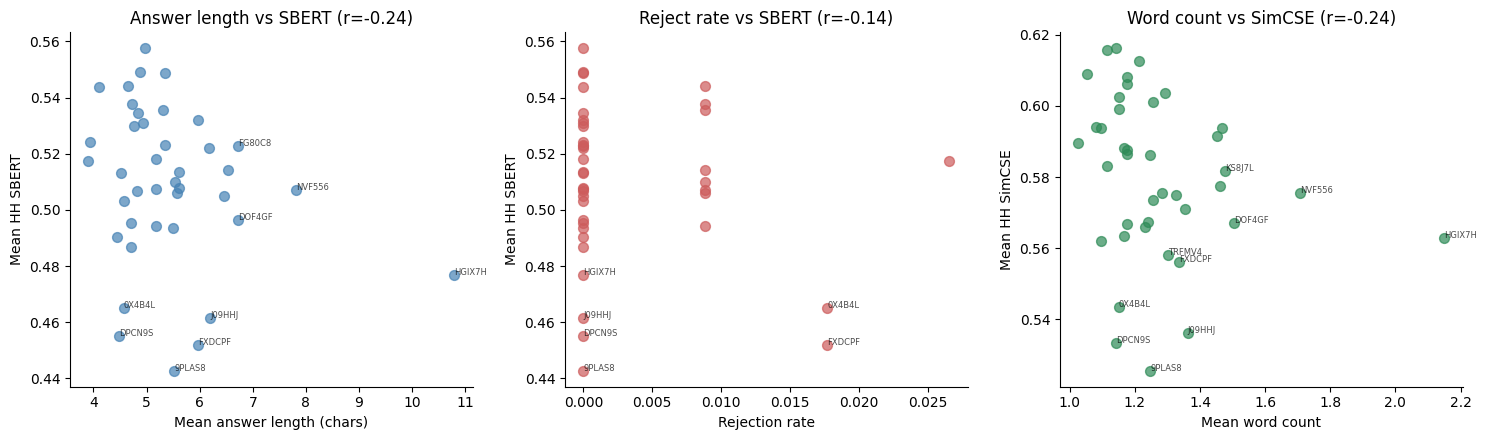

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Answer length vs SBERT
ax = axes[0]
ax.scatter(p_merged['mean_len'], p_merged['mean_sbert'], c='steelblue', alpha=0.7, s=50)
for pid, row in p_merged.iterrows():
    if row['mean_sbert'] < p_merged['mean_sbert'].quantile(0.15) or row['mean_len'] > p_merged['mean_len'].quantile(0.9):
        ax.annotate(pid[:6], (row['mean_len'], row['mean_sbert']), fontsize=6, alpha=0.7)
ax.set_xlabel('Mean answer length (chars)')
ax.set_ylabel('Mean HH SBERT')
r = p_merged['mean_len'].corr(p_merged['mean_sbert'])
ax.set_title(f'Answer length vs SBERT (r={r:.2f})')

# 2. Reject rate vs SBERT
ax = axes[1]
ax.scatter(p_merged['reject_rate'], p_merged['mean_sbert'], c='indianred', alpha=0.7, s=50)
for pid, row in p_merged.iterrows():
    if row['reject_rate'] > 0.1 or row['mean_sbert'] < p_merged['mean_sbert'].quantile(0.15):
        ax.annotate(pid[:6], (row['reject_rate'], row['mean_sbert']), fontsize=6, alpha=0.7)
ax.set_xlabel('Rejection rate')
ax.set_ylabel('Mean HH SBERT')
r = p_merged['reject_rate'].corr(p_merged['mean_sbert'])
ax.set_title(f'Reject rate vs SBERT (r={r:.2f})')

# 3. Word count vs SimCSE
ax = axes[2]
ax.scatter(p_merged['mean_words'], p_merged['mean_simcse'], c='seagreen', alpha=0.7, s=50)
for pid, row in p_merged.iterrows():
    if row['mean_simcse'] < p_merged['mean_simcse'].quantile(0.15) or row['mean_words'] > p_merged['mean_words'].quantile(0.9):
        ax.annotate(pid[:6], (row['mean_words'], row['mean_simcse']), fontsize=6, alpha=0.7)
ax.set_xlabel('Mean word count')
ax.set_ylabel('Mean HH SimCSE')
r = p_merged['mean_words'].corr(p_merged['mean_simcse'])
ax.set_title(f'Word count vs SimCSE (r={r:.2f})')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Detailed look at the bottom outliers

For the 5 lowest-SBERT participants, show:
- Their answer length / rejection stats
- Their most contrasting answer pairs (lowest SBERT vs. the majority answer)

In [5]:
# Bottom 5 outlier participants
bottom_5 = participant_stats.head(5).index.tolist()

# For each outlier, find their most contrasting HH pairs
for pid in bottom_5:
    print(f'\n{"="*70}')
    info = p_merged.loc[pid]
    print(f'Participant: {pid}')
    print(f'  Mean SBERT: {info["mean_sbert"]:.3f}  |  Mean SimCSE: {info["mean_simcse"]:.3f}')
    print(f'  Mean answer len: {info["mean_len"]:.1f} chars  |  Mean words: {info["mean_words"]:.1f}')
    print(f'  Reject rate: {info["reject_rate"]:.1%}  ({int(info["reject_count"])} / {int(info["n_answers"])})')
    print(f'  Mean accuracy: {info["mean_accuracy"]:.3f}')
    
    # Their worst pairs
    their_pairs = hh_flat[hh_flat['participant'] == pid].sort_values('sbert')
    print(f'\n  --- 10 most contrasting answer pairs (lowest SBERT) ---')
    for _, p in their_pairs.head(10).iterrows():
        print(f'  SBERT={p["sbert"]:.3f}  qid={p["question_id"]}')
        print(f'    {pid[:6]}: "{p["answer"]}"')
        print(f'    {p["other"][:6]}: "{p["other_answer"]}"')
    
    # Show their rejection answers
    their_answers = h_c[h_c['participant'] == pid]
    rejects = their_answers[their_answers['is_reject']]
    if len(rejects) > 0:
        print(f'\n  --- Rejection answers ({len(rejects)}) ---')
        for _, r in rejects.head(10).iterrows():
            print(f'    qid={r["question_id"]}: "{r["resp"]}"')


Participant: 9PLAS8J9
  Mean SBERT: 0.443  |  Mean SimCSE: 0.526
  Mean answer len: 5.5 chars  |  Mean words: 1.2
  Reject rate: 0.0%  (0 / 113)
  Mean accuracy: 0.248

  --- 10 most contrasting answer pairs (lowest SBERT) ---
  SBERT=-0.053  qid=537206001
    9PLAS8: "because it hurts if he gets injured"
    JOJCF2: "construction site"
  SBERT=-0.009  qid=506311007
    9PLAS8: "dolphins"
    HGIX7H: "very small leaf pattern"
  SBERT=-0.001  qid=91236000
    9PLAS8: "straight"
    TRFMV4: "selling expensive airfares"
  SBERT=0.007  qid=229391001
    9PLAS8: "gender"
    3BN3ZB: "they ride bicycles"
  SBERT=0.015  qid=537206001
    9PLAS8: "because it hurts if he gets injured"
    K8VD3T: "indoor"
  SBERT=0.015  qid=537206001
    9PLAS8: "because it hurts if he gets injured"
    85M7GI: "up"
  SBERT=0.015  qid=537206001
    9PLAS8: "because it hurts if he gets injured"
    KS8J7L: "up"
  SBERT=0.015  qid=537206001
    9PLAS8: "because it hurts if he gets injured"
    ON7P7X: "up"
  SBE

## 4. Answer length distribution: outliers vs. rest

Compare answer length distributions between the bottom-5 participants and the remaining participants. Also check if verbose answers (long) or terse answers (short) drive the low agreement.

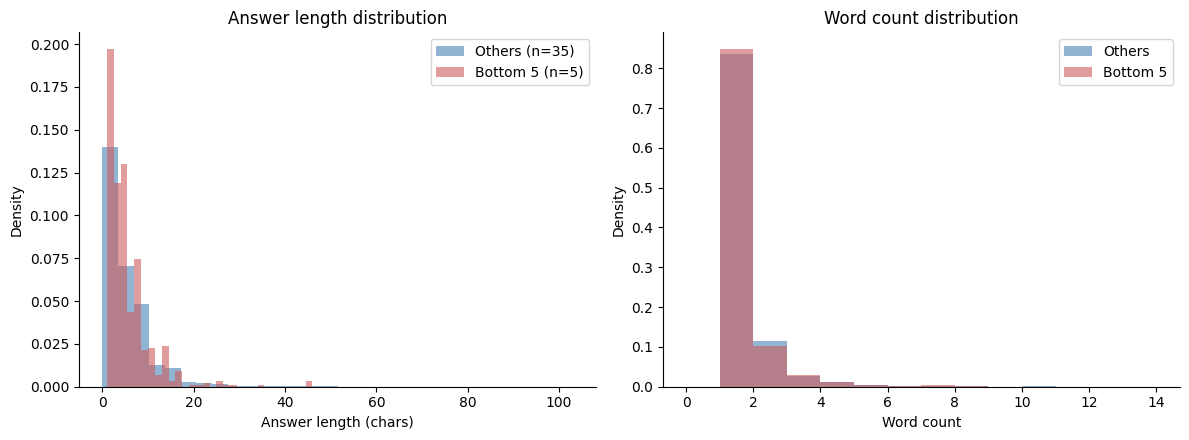

=== Length stats comparison ===
Bottom 5  : mean_len=5.3  median_len=4  mean_words=1.2  reject_rate=0.7%
Others    : mean_len=5.4  median_len=4  mean_words=1.3  reject_rate=0.3%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

outlier_set = set(bottom_5)
h_c['is_outlier'] = h_c['participant'].isin(outlier_set)

# 1. Answer length histogram
ax = axes[0]
ax.hist(h_c[~h_c['is_outlier']]['resp_len'], bins=30, alpha=0.6, 
        label=f'Others (n={h_c[~h_c["is_outlier"]]["participant"].nunique()})', 
        color='steelblue', density=True)
ax.hist(h_c[h_c['is_outlier']]['resp_len'], bins=30, alpha=0.6, 
        label=f'Bottom 5 (n=5)', color='indianred', density=True)
ax.set_xlabel('Answer length (chars)')
ax.set_ylabel('Density')
ax.set_title('Answer length distribution')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 2. Word count histogram
ax = axes[1]
ax.hist(h_c[~h_c['is_outlier']]['word_count'], bins=range(0, 15), alpha=0.6, 
        label='Others', color='steelblue', density=True)
ax.hist(h_c[h_c['is_outlier']]['word_count'], bins=range(0, 15), alpha=0.6, 
        label='Bottom 5', color='indianred', density=True)
ax.set_xlabel('Word count')
ax.set_ylabel('Density')
ax.set_title('Word count distribution')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Stats comparison
print('=== Length stats comparison ===')
for label, mask in [('Bottom 5', h_c['is_outlier']), ('Others', ~h_c['is_outlier'])]:
    sub = h_c[mask]
    print(f'{label:10s}: mean_len={sub["resp_len"].mean():.1f}  '
          f'median_len={sub["resp_len"].median():.0f}  '
          f'mean_words={sub["word_count"].mean():.1f}  '
          f'reject_rate={sub["is_reject"].mean():.1%}')

## 5. Per-question SBERT: is it the participant or specific questions?

Check whether the low-agreement participants are uniformly bad across all questions, or if specific questions drive the divergence.

In [7]:
# Per (participant, question) mean SBERT across all their HH pairs for that question
pq = hh_flat.groupby(['participant', 'question_id']).agg(
    mean_sbert=('sbert', 'mean'),
    n_partners=('other', 'nunique'),
).reset_index()

# Compare outlier vs. others per question
pq['is_outlier'] = pq['participant'].isin(outlier_set)

# For each question, compute mean SBERT for outliers vs. others
q_comp = pq.groupby(['question_id', 'is_outlier'])['mean_sbert'].mean().unstack('is_outlier')
q_comp.columns = ['others', 'outliers']
q_comp['gap'] = q_comp['others'] - q_comp['outliers']
q_comp = q_comp.sort_values('gap', ascending=False)

print('=== Questions where outliers diverge most from others ===')
display(q_comp.head(15).round(3))

print(f'\n=== Questions where outliers AGREE more than others ===')
display(q_comp.tail(5).round(3))

# Merge with question text
q_text = h_c[['question_id', 'question_en', 'op', 'ent']].drop_duplicates('question_id')
q_comp_full = q_comp.reset_index().merge(q_text, on='question_id')

print('\n=== Top divergent questions with context ===')
for _, row in q_comp_full.head(10).iterrows():
    print(f'  gap={row["gap"]:.3f}  [{row["op"]}/{row["ent"]}]  qid={row["question_id"]}')
    print(f'    Q: {row["question_en"]}')

=== Questions where outliers diverge most from others ===


,others,outliers,gap
question_id,,,
67551002,0.658,0.395,0.263
450970001,0.753,0.525,0.228
74711004,0.617,0.389,0.228
271934000,0.676,0.454,0.222
13546003,0.757,0.536,0.220
322031002,0.713,0.498,0.215
133928008,0.709,0.495,0.215
473110009,0.766,0.559,0.207
121442004,0.640,0.454,0.186



=== Questions where outliers AGREE more than others ===


,others,outliers,gap
question_id,,,
546577001,0.617,0.641,-0.024
96618004,0.726,0.752,-0.026
559483008,0.309,0.335,-0.027
293218002,0.561,0.594,-0.034
394002002,0.320,0.432,-0.112



=== Top divergent questions with context ===
  gap=0.263  [count/other]  qid=67551002
    Q: How many colors are on the blanket on the elephant back?
  gap=0.228  [count/object]  qid=450970001
    Q: How many red suitcases?
  gap=0.228  [count/animal]  qid=74711004
    Q: How many birds?
  gap=0.222  [know/place]  qid=271934000
    Q: What religion is this building associated with?
  gap=0.220  [count/object]  qid=13546003
    Q: How many benches are in the background?
  gap=0.215  [count/person]  qid=322031002
    Q: How many people touching the elephant trunk?
  gap=0.215  [count/object]  qid=133928008
    Q: How many cranes are in this image?
  gap=0.207  [count/object]  qid=473110009
    Q: How many train track are there?
  gap=0.186  [count/person]  qid=121442004
    Q: How many kids have glasses?
  gap=0.167  [count/object]  qid=164453003
    Q: How many hearts are on the desk?


## 6. Side-by-side: outlier answers vs. majority consensus

For the top divergent questions, show what each outlier answered vs. the most common answer from other participants.

In [8]:
# For top-10 most divergent questions, show outlier answers vs. consensus
top_div_qids = q_comp_full.head(10)['question_id'].tolist()

for qid in top_div_qids:
    q_row = q_text[q_text['question_id'] == qid].iloc[0]
    print(f'\n{"─"*70}')
    print(f'Q{qid} [{q_row["op"]}/{q_row["ent"]}]: {q_row["question_en"]}')
    
    q_answers = h_c[h_c['question_id'] == qid]
    
    # Consensus: most common answer from non-outliers
    others_ans = q_answers[~q_answers['is_outlier']]['resp']
    consensus = others_ans.value_counts()
    print(f'  Consensus (top 3): {dict(consensus.head(3))}')
    
    # Outlier answers
    outlier_ans = q_answers[q_answers['is_outlier']][['participant', 'resp', 'resp_len']]
    for _, oa in outlier_ans.iterrows():
        marker = '  ⚠' if oa['resp_len'] > others_ans.str.len().quantile(0.9) else '   '
        print(f'{marker} {oa["participant"][:6]}: "{oa["resp"]}"  (len={oa["resp_len"]})')


──────────────────────────────────────────────────────────────────────
Q67551002 [count/other]: How many colors are on the blanket on the elephant back?
  Consensus (top 3): {'3': 11, '1': 7, '2': 6}
  ⚠ 0X4B4L: "324"  (len=3)
    9PLAS8: "6"  (len=1)
  ⚠ DPCN9S: "do not say strange things"  (len=25)
  ⚠ FXDCPF: "1 color"  (len=7)
  ⚠ J09HHJ: "18"  (len=2)

──────────────────────────────────────────────────────────────────────
Q450970001 [count/object]: How many red suitcases?
  Consensus (top 3): {'1': 13, '2': 11, '3': 6}
  ⚠ 0X4B4L: "453"  (len=3)
    9PLAS8: "0"  (len=1)
  ⚠ DPCN9S: "34"  (len=2)
    FXDCPF: "0"  (len=1)
    J09HHJ: "0"  (len=1)

──────────────────────────────────────────────────────────────────────
Q74711004 [count/animal]: How many birds?
  Consensus (top 3): {'3': 11, '4': 7, '2': 4}
    0X4B4L: "113"  (len=3)
  ⚠ 9PLAS8: "309 birds"  (len=9)
    DPCN9S: "19"  (len=2)
    FXDCPF: "1 bird"  (len=6)
    J09HHJ: "54"  (len=2)

─────────────────────────────────────

## 7. Length-driven SBERT penalty check

Directly test whether SBERT/SimCSE penalizes length mismatches. For all HH pairs, compare the absolute length difference to the SBERT score.

/tmp/ipykernel_98330/1764596739.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = hh_len.groupby(bins).agg(
/tmp/ipykernel_98330/1764596739.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned2 = hh_len.groupby(bins2).agg(


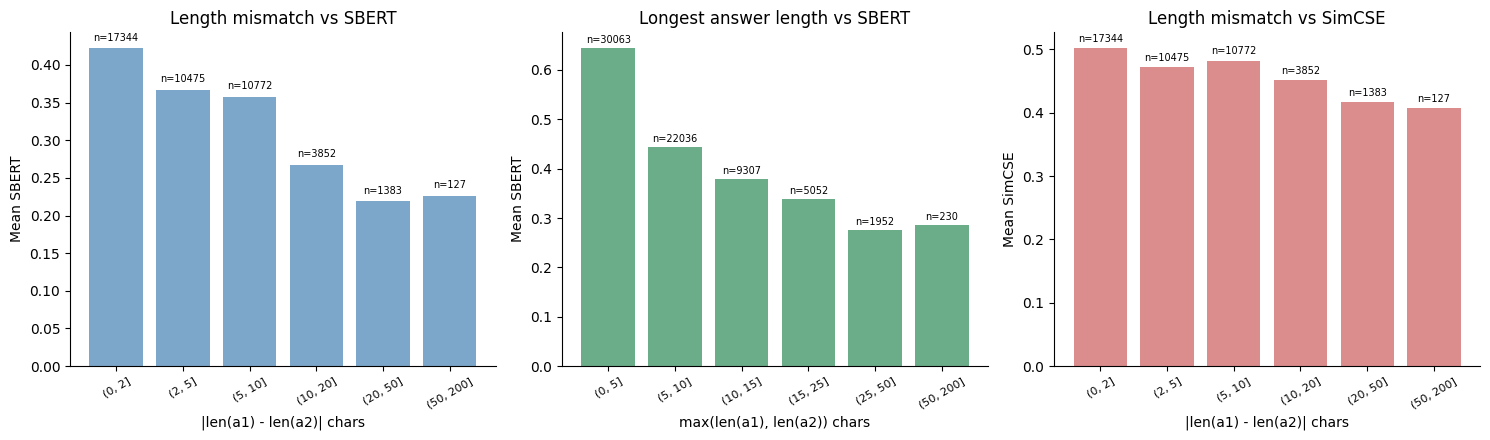

Pearson r (len_diff vs sbert):  -0.417
Pearson r (len_diff vs simcse): -0.327
Pearson r (max_len vs sbert):   -0.397


In [9]:
# Add lengths to HH pairs
hh_len = hh.copy()
hh_len['len_1'] = hh_len['answer_1'].fillna('').str.len()
hh_len['len_2'] = hh_len['answer_2'].fillna('').str.len()
hh_len['len_diff'] = (hh_len['len_1'] - hh_len['len_2']).abs()
hh_len['len_ratio'] = hh_len[['len_1', 'len_2']].max(axis=1) / (hh_len[['len_1', 'len_2']].min(axis=1) + 1)
hh_len['max_len'] = hh_len[['len_1', 'len_2']].max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Length diff vs SBERT
ax = axes[0]
# Bin by length diff
bins = pd.cut(hh_len['len_diff'], bins=[0, 2, 5, 10, 20, 50, 200], right=True)
binned = hh_len.groupby(bins).agg(
    mean_sbert=('sbert_score', 'mean'),
    mean_simcse=('simcse_score', 'mean'),
    count=('sbert_score', 'count'),
)
ax.bar(range(len(binned)), binned['mean_sbert'], color='steelblue', alpha=0.7)
ax.set_xticks(range(len(binned)))
ax.set_xticklabels([str(b) for b in binned.index], rotation=30, fontsize=8)
ax.set_xlabel('|len(a1) - len(a2)| chars')
ax.set_ylabel('Mean SBERT')
ax.set_title('Length mismatch vs SBERT')
# Add counts
for i, (_, row) in enumerate(binned.iterrows()):
    ax.text(i, row['mean_sbert'] + 0.01, f'n={int(row["count"])}', ha='center', fontsize=7)

# 2. Max length vs SBERT  
ax = axes[1]
bins2 = pd.cut(hh_len['max_len'], bins=[0, 5, 10, 15, 25, 50, 200], right=True)
binned2 = hh_len.groupby(bins2).agg(
    mean_sbert=('sbert_score', 'mean'),
    mean_simcse=('simcse_score', 'mean'),
    count=('sbert_score', 'count'),
)
ax.bar(range(len(binned2)), binned2['mean_sbert'], color='seagreen', alpha=0.7)
ax.set_xticks(range(len(binned2)))
ax.set_xticklabels([str(b) for b in binned2.index], rotation=30, fontsize=8)
ax.set_xlabel('max(len(a1), len(a2)) chars')
ax.set_ylabel('Mean SBERT')
ax.set_title('Longest answer length vs SBERT')
for i, (_, row) in enumerate(binned2.iterrows()):
    ax.text(i, row['mean_sbert'] + 0.01, f'n={int(row["count"])}', ha='center', fontsize=7)

# 3. Same for SimCSE
ax = axes[2]
ax.bar(range(len(binned)), binned['mean_simcse'], color='indianred', alpha=0.7)
ax.set_xticks(range(len(binned)))
ax.set_xticklabels([str(b) for b in binned.index], rotation=30, fontsize=8)
ax.set_xlabel('|len(a1) - len(a2)| chars')
ax.set_ylabel('Mean SimCSE')
ax.set_title('Length mismatch vs SimCSE')
for i, (_, row) in enumerate(binned.iterrows()):
    ax.text(i, row['mean_simcse'] + 0.01, f'n={int(row["count"])}', ha='center', fontsize=7)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Pearson r (len_diff vs sbert):  {hh_len["len_diff"].corr(hh_len["sbert_score"]):.3f}')
print(f'Pearson r (len_diff vs simcse): {hh_len["len_diff"].corr(hh_len["simcse_score"]):.3f}')
print(f'Pearson r (max_len vs sbert):   {hh_len["max_len"].corr(hh_len["sbert_score"]):.3f}')